# Part B – Q1.2: Exploratory Data Analysis (EDA)
**Dataset:** IMDB Dataset of 50,000 Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Dataset Overview

In [8]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('IMDB Dataset.csv')

# Encode sentiment as numeric label for later use
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("=" * 45)
print("         DATASET Overview")
print("=" * 45)
print(f"  Total reviews    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 45)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 3 rows:")
df.head(3)


         DATASET Overview
  Total reviews    : 50,000
  Columns          : ['review', 'sentiment', 'label']
  Missing values   : 0
  Duplicate rows   : 418

Data Types:
review       object
sentiment    object
label         int64
dtype: object

First 3 rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


## 2. Class Distribution

Sentiment Distribution:
  Positive : 25,000  (50.0%)
  Negative : 25,000  (50.0%)


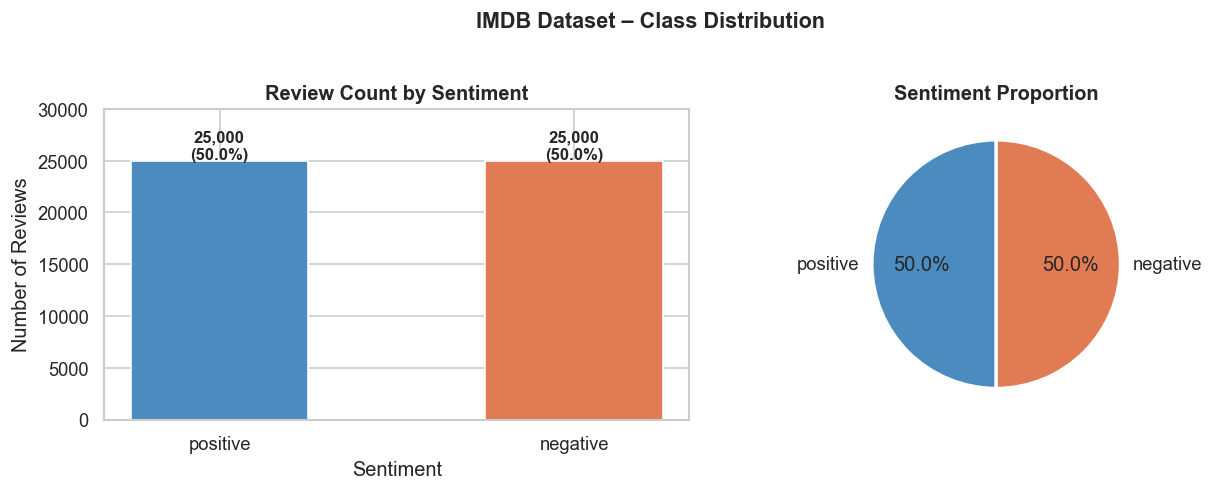

In [9]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df['sentiment'].value_counts()
pcts   = df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
print(f"  Positive : {counts['positive']:,}  ({pcts['positive']:.1f}%)")
print(f"  Negative : {counts['negative']:,}  ({pcts['negative']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#4C8BBF', '#E07B54']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Review Count by Sentiment', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 30000)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion', fontweight='bold')

plt.suptitle('IMDB Dataset – Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Review Length Analysis

Review Length Statistics (Word Count):
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


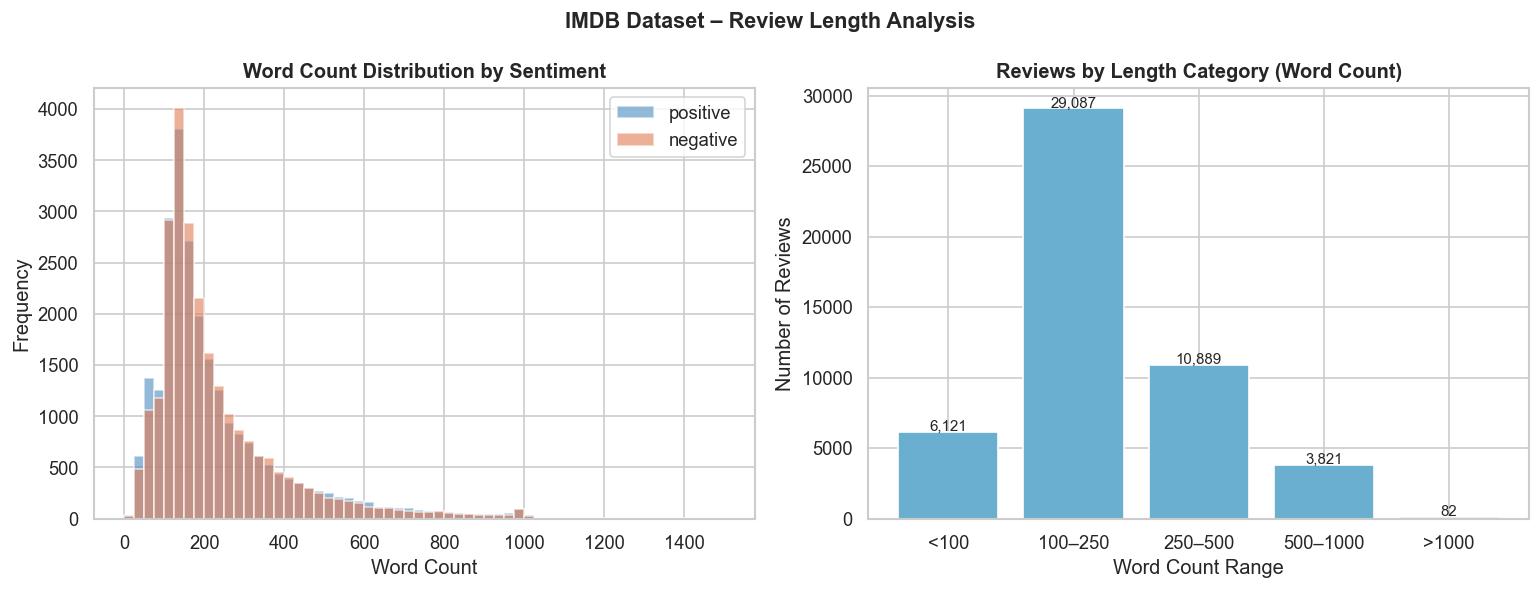

In [10]:
# ── Compute review lengths ────────────────────────────────────────────────────
df['word_count'] = df['review'].str.split().str.len()

print("Review Length Statistics (Word Count):")
print(df.groupby('sentiment')['word_count'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Word count histogram by sentiment
for label, color in zip(['positive', 'negative'], ['#4C8BBF', '#E07B54']):
    subset = df[df['sentiment'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=label, range=(0, 1500))
axes[0].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review length buckets
bins   = [0, 100, 250, 500, 1000, df['word_count'].max()]
labels = ['<100', '100–250', '250–500', '500–1000', '>1000']
df['length_bucket'] = pd.cut(df['word_count'], bins=bins, labels=labels)
bucket_counts = df['length_bucket'].value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color='#6AAFCF', edgecolor='white')
axes[1].set_title('Reviews by Length Category (Word Count)', fontweight='bold')
axes[1].set_xlabel('Word Count Range')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('IMDB Dataset – Review Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Vocabulary & Descriptive Statistics

Descriptive Statistics Summary:
           word_count  unique_words  lexical_richness
sentiment                                            
negative       229.46        139.44              0.66
positive       232.85        139.25              0.65


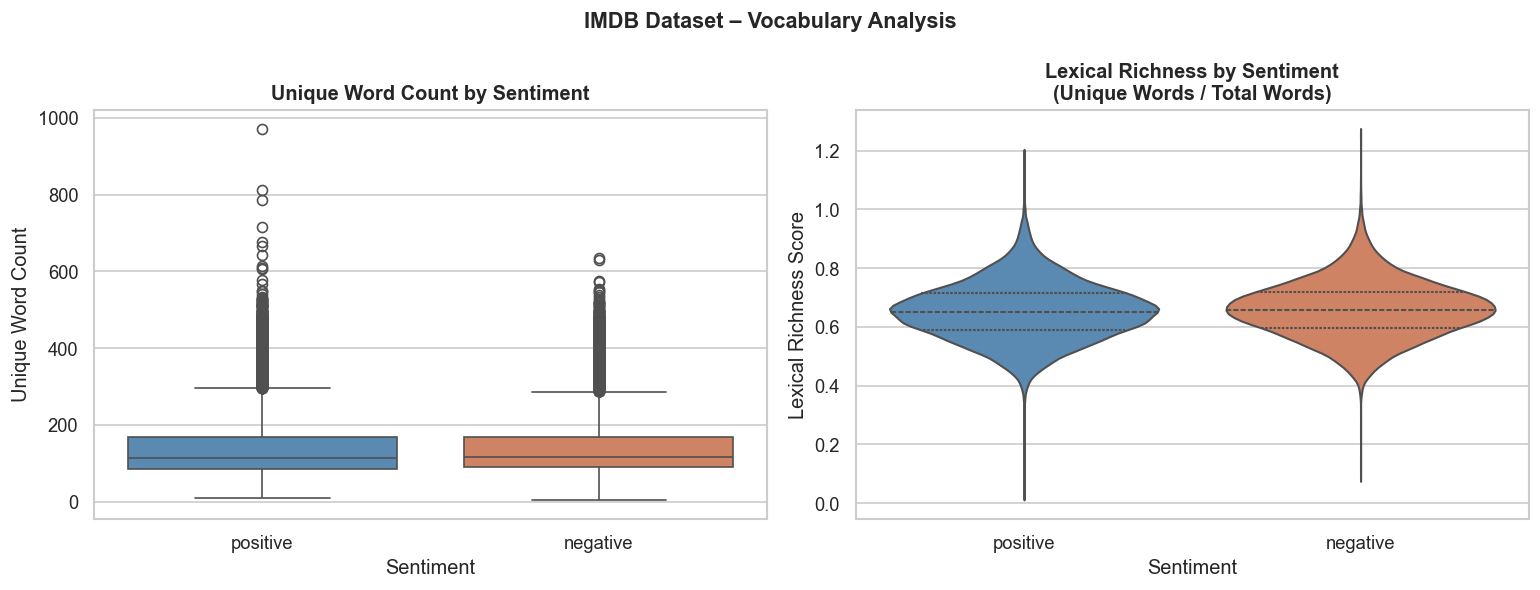

In [13]:
# ── Unique word count per review ──────────────────────────────────────────────
df['unique_words'] = df['review'].apply(
    lambda x: len(set(re.sub(r'[^a-zA-Z]', ' ', x).lower().split()))
)

# ── Lexical richness = unique words / total words ─────────────────────────────
df['lexical_richness'] = df['unique_words'] / df['word_count']

print("Descriptive Statistics Summary:")
stats = df.groupby('sentiment')[['word_count', 'unique_words', 'lexical_richness']].mean().round(2)
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Unique words boxplot
sns.boxplot(data=df, x='sentiment', y='unique_words',
            palette={'positive': '#4C8BBF', 'negative': '#E07B54'}, ax=axes[0])
axes[0].set_title('Unique Word Count by Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Unique Word Count')

# Lexical richness violin
sns.violinplot(data=df, x='sentiment', y='lexical_richness',
               palette={'positive': '#4C8BBF', 'negative': '#E07B54'},
               inner='quartile', ax=axes[1])
axes[1].set_title('Lexical Richness by Sentiment\n(Unique Words / Total Words)', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Lexical Richness Score')

plt.suptitle('IMDB Dataset – Vocabulary Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. EDA Summary & Key Findings

In [14]:
# ── Print consolidated EDA summary ───────────────────────────────────────────
print("=" * 55)
print("             EDA SUMMARY – IMDB DATASET")
print("=" * 55)
print(f"  Total reviews          : {len(df):,}")
print(f"  Positive reviews       : {(df['sentiment']=='positive').sum():,} (50%)")
print(f"  Negative reviews       : {(df['sentiment']=='negative').sum():,} (50%)")
print(f"  Missing values         : {df[['review','sentiment']].isnull().sum().sum()}")
print(f"  Duplicate rows         : {df.duplicated(subset=['review']).sum()}")
print()
print("  --- Review Length (Word Count) ---")
print(f"  Overall mean           : {df['word_count'].mean():.1f} words")
print(f"  Overall median         : {df['word_count'].median():.1f} words")
print(f"  Min / Max              : {df['word_count'].min()} / {df['word_count'].max()}")
print()
print("  --- Per Sentiment (Mean Word Count) ---")
for s in ['positive', 'negative']:
    m = df[df['sentiment']==s]['word_count'].mean()
    print(f"  {s.capitalize():<12}         : {m:.1f} words")
print()
print("  --- Vocabulary ---")
print(f"  Avg unique words/review: {df['unique_words'].mean():.1f}")
print(f"  Avg lexical richness   : {df['lexical_richness'].mean():.3f}")




             EDA SUMMARY – IMDB DATASET
  Total reviews          : 50,000
  Positive reviews       : 25,000 (50%)
  Negative reviews       : 25,000 (50%)
  Missing values         : 0
  Duplicate rows         : 418

  --- Review Length (Word Count) ---
  Overall mean           : 231.2 words
  Overall median         : 173.0 words
  Min / Max              : 4 / 2470

  --- Per Sentiment (Mean Word Count) ---
  Positive             : 232.8 words
  Negative             : 229.5 words

  --- Vocabulary ---
  Avg unique words/review: 139.3
  Avg lexical richness   : 0.657
